In [1]:
import pyccl as ccl
ccl.__version__
import numpy as np
import matplotlib.pylab as plt

# Create pyccl 'cosmo' object for different scenarios:

In [2]:


#we will set two models- LCDM like:
cosmo = ccl.Cosmology(Omega_c= 0.35, Omega_b=0.05, 
                       h=0.8, n_s=0.96, sigma8=0.8, Omega_k=0.0)


#we will set two models- Dark energy variable using that the dark energy evolves like w=w0+wa(1=a):
cosmo_variable = ccl.Cosmology(Omega_c= 0.35, Omega_b=0.05, 
                       h=0.8, n_s=0.96, sigma8=0.8, Omega_k=0.0,
                       w0= -.2, wa= -.9, extra_parameters={"camb": {"dark_energy_model": "ppf"}})

 

# Read the redshift distribution for a LSST-like survey (galaxy and weak lensing distributions)

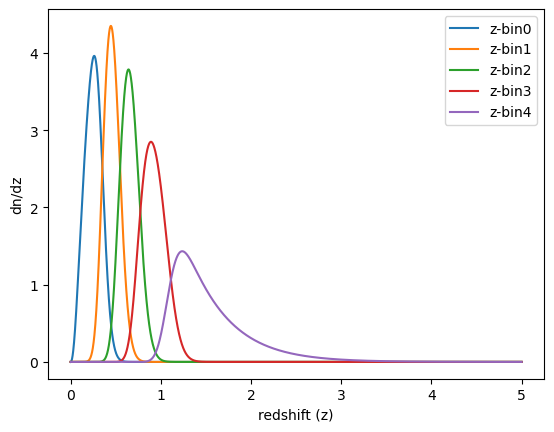

In [3]:
pz_path = '/home/s1/ggibbins/practice/lsst_like_dndz/' #where you saved the files from google drive

nside = 1024
ell = np.arange(0,  3*nside+1)

tracers_dndz = []
for i in range(5):
    
    zz,nz= np.load(pz_path+'NZ_sourcegalaxies_bin_'+str(i)+'.npy' )
    
    tracers_dndz.append(nz)
     
    plt.plot(zz,nz, label='z-bin'+str(i))
plt.ylabel('dn/dz')
plt.xlabel('redshift (z)')
plt.legend()

tracers_dndz = np.array(tracers_dndz)

# Once we know how the galaxies are distributed in terms of redshift, let's make the prediction about the power spectrum:

Text(0.5, 0, '$\\ell$')

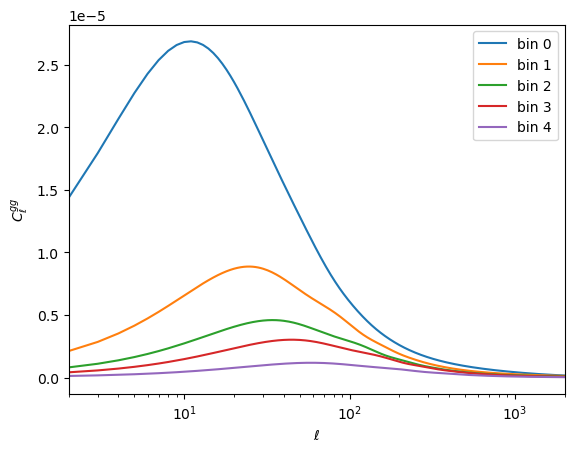

In [4]:
bias_z = [1.0, 1.1, 1.2, 1.5, 2.0]
ell = np.arange(3*1024+1)
for i in range(5):
    
    
    ccl_z = ccl.NumberCountsTracer(cosmo,False,(zz,tracers_dndz[i]), bias= (zz,  bias_z[i]*np.ones(len(zz)) )) #<-- Here we use 'cosmo' consisting LCDM model, but we could
    #check for the cosmo_variable and check how it changes for different cosmologies...
    cl_gg_th = ccl.angular_cl(cosmo, ccl_z,ccl_z, ell)

    plt.plot(ell, cl_gg_th, label='bin '+str(i))

plt.xscale('log')
plt.xlim(2,2000)
plt.legend()
plt.ylabel(r'$C_{\ell}^{gg}$')
plt.xlabel(r'$\ell$')
    

LCDM [3.72209392e-06 9.73101028e-06 1.43705286e-05 ... 7.78725162e-08
 7.78255381e-08 7.77785994e-08]

 Dynamic: [4.91792485e-06 1.24015376e-05 1.82209903e-05 ... 1.10194750e-07
 1.10129619e-07 1.10064542e-07]

 DIFFERENCE [-1.19583093e-06 -2.67052729e-06 -3.85046175e-06 ... -3.23222342e-08
 -3.23040812e-08 -3.22859427e-08] 

LCDM [4.68975538e-07 1.32591667e-06 2.11774971e-06 ... 7.33471751e-08
 7.33129242e-08 7.32786950e-08]

 Dynamic: [7.85986939e-07 2.18255669e-06 3.42022025e-06 ... 1.11912963e-07
 1.11860559e-07 1.11808188e-07]

 DIFFERENCE [-3.17011402e-07 -8.56640022e-07 -1.30247054e-06 ... -3.85657880e-08
 -3.85476349e-08 -3.85294935e-08] 

LCDM [1.76971341e-07 5.03689816e-07 8.11433257e-07 ... 5.25246664e-08
 5.25042390e-08 5.24838234e-08]

 Dynamic: [3.20521495e-07 9.14945485e-07 1.45140008e-06 ... 8.51019806e-08
 8.50685149e-08 8.50350682e-08]

 DIFFERENCE [-1.43550153e-07 -4.11255669e-07 -6.39966827e-07 ... -3.25773143e-08
 -3.25642759e-08 -3.25512448e-08] 

LCDM [9.03605650

"\n#USES LINEAR EVOLUTION OF DM\nfor i in range(5):\n    ccl_z2 = ccl.NumberCountsTracer(cosmo_variable,False,(zz,tracers_dndz[i]), bias= (zz,  bias_z[i]*np.ones(len(zz))))\n    cl_gg_th2 = ccl.angular_cl(cosmo_variable, ccl_z2,ccl_z2, ell)\n    print('\n','Dynamic:',cl_gg_th2)\n    axs[1].plot(ell, cl_gg_th2, label='bin '+str(i))\n"

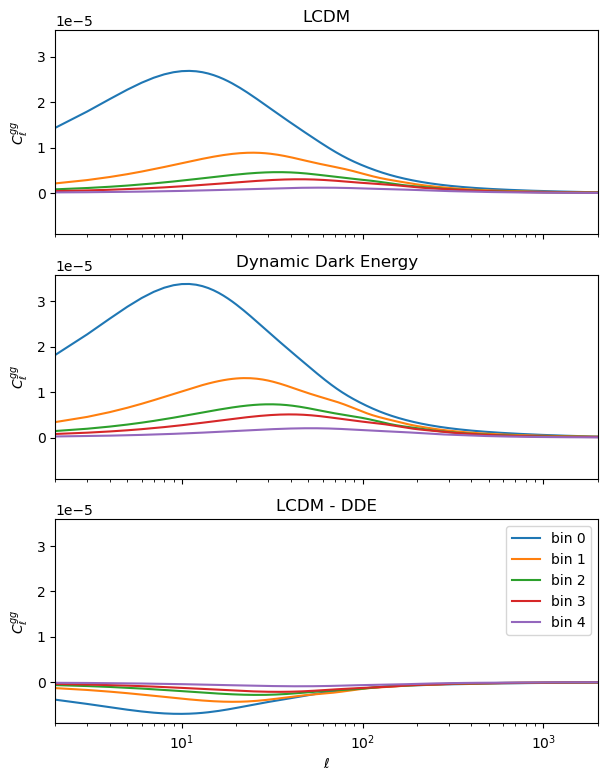

In [5]:
#trying to figure out why weak lensing plots are same for DDE and LCDM --> not same j very similar

fig, axs = plt.subplots(3, sharex=True, sharey=True, figsize=(7,9))

plt.xlim(2,2000)
axs[0].set_ylabel(r'$C_{\ell}^{gg}$')
axs[1].set_ylabel(r'$C_{\ell}^{gg}$')
axs[2].set_ylabel(r'$C_{\ell}^{gg}$')
plt.xlabel(r'$\ell$')
axs[0].set_title("LCDM")
axs[1].set_title("Dynamic Dark Energy")
axs[2].set_title("LCDM - DDE")
plt.xscale('log')

bias_z = [1.0, 1.1, 1.2, 1.5, 2.0]
ell = np.arange(3*1024+1)


for i in range(5):

    #LCDM
    ccl_z = ccl.NumberCountsTracer(cosmo,False,(zz,tracers_dndz[i]), bias= (zz,  bias_z[i]*np.ones(len(zz)) ))
    cl_gg_th = ccl.angular_cl(cosmo, ccl_z,ccl_z, ell)
    print('LCDM', cl_gg_th)
    axs[0].plot(ell, cl_gg_th, label='bin '+str(i))

    #DDE
    ccl_z2 = ccl.NumberCountsTracer(cosmo_variable,False,(zz,tracers_dndz[i]), bias= (zz,  bias_z[i]*np.ones(len(zz))))
    cl_gg_th2 = ccl.angular_cl(cosmo_variable, ccl_z2,ccl_z2, ell)
    print('\n','Dynamic:',cl_gg_th2)
    axs[1].plot(ell, cl_gg_th2, label='bin '+str(i))

    #LCDM - DDE
    diff = cl_gg_th - cl_gg_th2
    print("\n", "DIFFERENCE",diff, "\n")
    axs[2].plot(ell, diff, label='bin '+str(i))

plt.legend()

'''
#USES LINEAR EVOLUTION OF DM
for i in range(5):
    ccl_z2 = ccl.NumberCountsTracer(cosmo_variable,False,(zz,tracers_dndz[i]), bias= (zz,  bias_z[i]*np.ones(len(zz))))
    cl_gg_th2 = ccl.angular_cl(cosmo_variable, ccl_z2,ccl_z2, ell)
    print('\n','Dynamic:',cl_gg_th2)
    axs[1].plot(ell, cl_gg_th2, label='bin '+str(i))
'''

# Next we would make a similar approach for other probes, such as CMB lensing and galaxy weak lensing and using 'cosmo_variable'..

LCDM [0.00000000e+00 0.00000000e+00 4.90681796e-09 ... 4.57965241e-12
 4.57657260e-12 4.57349574e-12]
Dynamic [0.00000000e+00 0.00000000e+00 4.90681796e-09 ... 4.57965241e-12
 4.57657260e-12 4.57349574e-12]

 DIFFERENCE [ 0.00000000e+00  0.00000000e+00  2.50506692e-10 ... -6.23189728e-14
 -6.23218045e-14 -6.23246060e-14] 

LCDM [0.00000000e+00 0.00000000e+00 8.39042947e-09 ... 2.42500325e-11
 2.42349363e-11 2.42198533e-11]
Dynamic [0.00000000e+00 0.00000000e+00 8.39042947e-09 ... 2.42500325e-11
 2.42349363e-11 2.42198533e-11]

 DIFFERENCE [0.00000000e+00 0.00000000e+00 4.93163483e-10 ... 1.19008296e-12
 1.18918125e-12 1.18828038e-12] 

LCDM [0.00000000e+00 0.00000000e+00 1.05020840e-08 ... 5.82601324e-11
 5.82267759e-11 5.81934463e-11]
Dynamic [0.00000000e+00 0.00000000e+00 1.05020840e-08 ... 5.82601324e-11
 5.82267759e-11 5.81934463e-11]

 DIFFERENCE [0.00000000e+00 0.00000000e+00 6.19013036e-10 ... 4.51831070e-12
 4.51558411e-12 4.51285966e-12] 

LCDM [0.00000000e+00 0.00000000e+00 1

'\naxs[0].set_ylim(-.5,4.5)\naxs[1].set_ylim(-.5,4.5)\naxs[2].set_ylim(-1,1)\n'

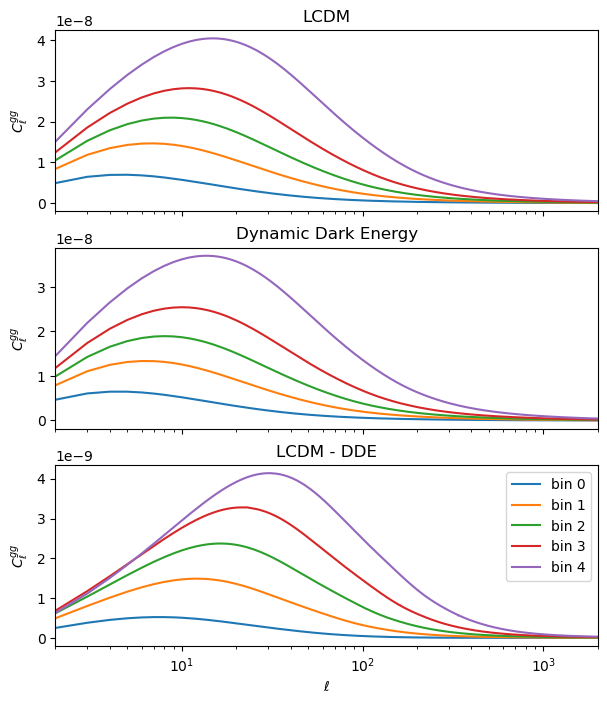

In [6]:
# ccl_z = ccl.WeakLensingTracer(cosmo, (zz,nz) )
# cl_kk_th = ccl.angular_cl(cosmo, ccl_z,ccl_z, ell)

# ccl_z2 = ccl.WeakLensingTracer(cosmo_variable, (zz,nz) )
# cl_kk_th2 = ccl.angular_cl(cosmo_variable, ccl_z2,ccl_z2, ell)

fig, axs = plt.subplots(3, sharex=True, figsize=(7,8))

plt.xlim(2,2000)



plt.xlabel(r'$\ell$')
axs[0].set_ylabel(r'$C_{\ell}^{gg}$')
axs[1].set_ylabel(r'$C_{\ell}^{gg}$')
axs[2].set_ylabel(r'$C_{\ell}^{gg}$')

axs[0].set_title("LCDM")
axs[1].set_title("Dynamic Dark Energy")
axs[2].set_title("LCDM - DDE")

plt.xscale('log')

bias_z = [1.0, 1.1, 1.2, 1.5, 2.0]
ell = np.arange(3*1024+1)


for i in range(5):
    #LCDM
    ccl_z = ccl.WeakLensingTracer(cosmo,(zz,tracers_dndz[i]), (zz,  bias_z[i]*np.ones(len(zz))))
    cl_gg_th = ccl.angular_cl(cosmo, ccl_z,ccl_z, ell)
    print('LCDM', cl_gg_th)
    axs[0].plot(ell, cl_gg_th, label='bin '+str(i))

    #DDE
    ccl_z2 = ccl.WeakLensingTracer(cosmo_variable,(zz,tracers_dndz[i]), (zz,  bias_z[i]*np.ones(len(zz))))
    cl_gg_th2 = ccl.angular_cl(cosmo_variable, ccl_z2,ccl_z2, ell)
    print('Dynamic', cl_gg_th)
    axs[1].plot(ell, cl_gg_th2, label='bin '+str(i))

    #LCDM - DDE
    diff = cl_gg_th - cl_gg_th2
    print("\n", "DIFFERENCE",diff, "\n")
    axs[2].plot(ell, diff, label='bin '+str(i))

plt.legend()
'''
axs[0].set_ylim(-.5,4.5)
axs[1].set_ylim(-.5,4.5)
axs[2].set_ylim(-1,1)
'''

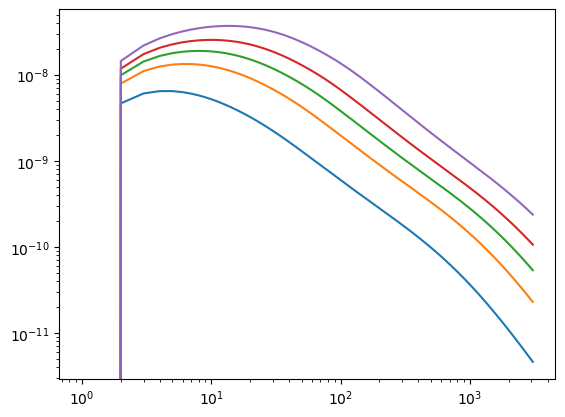

In [8]:
plt.yscale('log')
plt.xscale('log')

for i in range(5):
    ccl_z2 = ccl.WeakLensingTracer(cosmo_variable,(zz,tracers_dndz[i]), (zz,  bias_z[i]*np.ones(len(zz))))
    cl_gg_th2 = ccl.angular_cl(cosmo_variable, ccl_z2,ccl_z2, ell)

    plt.plot(ell, cl_gg_th2, label='bin '+str(i))

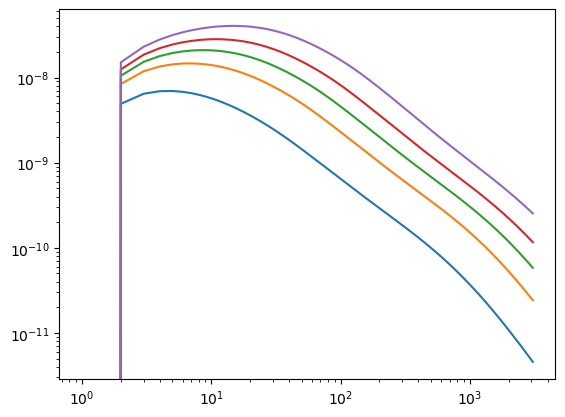

In [9]:
plt.yscale('log')
plt.xscale('log')

for i in range(5):    
    ccl_z = ccl.WeakLensingTracer(cosmo,(zz,tracers_dndz[i]), (zz,  bias_z[i]*np.ones(len(zz))))
    cl_gg_th = ccl.angular_cl(cosmo, ccl_z,ccl_z, ell)
    
    plt.plot(ell, cl_gg_th, label='bin '+str(i))